# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

[Te proporcionamos algunos comentarios para orientarte mientras completas este proyecto. Pero debes asegurarte de eliminar todos los comentarios entre corchetes antes de entregar tu proyecto.]

[Antes de sumergirte en el análisis de datos, explica por tu propia cuenta el propósito del proyecto y las acciones que planeas realizar.]

[Ten en cuenta que estudiar, modificar y analizar datos es un proceso iterativo. Es normal volver a los pasos anteriores y corregirlos/ampliarlos para permitir nuevos pasos.]

## Inicialización

In [2301]:
# Cargar todas las librerías
import numpy as np
import pandas as pd
import math as mt
import seaborn as sns
from matplotlib import pyplot as plt
from math import factorial
from scipy import stats as st

## Cargar datos

In [2302]:
# Carga los archivos de datos en diferentes DataFrames

df_tarifas = pd.read_csv('megaline_plans.csv')
df_usuarios = pd.read_csv('megaline_users.csv')
df_llamadas = pd.read_csv('megaline_calls.csv')
df_mensajes = pd.read_csv('megaline_messages.csv')
df_internet = pd.read_csv('megaline_internet.csv')


## Preparar los datos

[Los datos para este proyecto se dividen en varias tablas. Explora cada una para tener una comprensión inicial de los datos. Si es necesario, haz las correcciones requeridas en cada tabla.]

## Tarifas

In [2303]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas
df_tarifas.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 260.0+ bytes


In [2304]:
# Imprime una muestra de los datos para las tarifas
df_tarifas.head()


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

## Corregir datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

## Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

## Usuarios/as

In [2305]:
# Imprime la información general/resumida sobre el DataFrame de usuarios
df_usuarios.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [2306]:
# Imprime una muestra de datos para usuarios
df_usuarios.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [2307]:
# Buscar duplicados en los datos 
print(df_usuarios.duplicated().sum())
print(df_usuarios.duplicated(subset=['user_id']).sum()) 

# Transformar la columna 'reg_date' a formato datetime
df_usuarios['reg_date'] = pd.to_datetime(df_usuarios['reg_date'])

# Mostrar los tipos de datos para verificar la transformación
df_usuarios.info()
df_usuarios.head()

0
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 31.4+ KB


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [2308]:
# Crear la nueva columna 'month' extrayendo el mes
df_usuarios['month'] = df_usuarios['reg_date'].dt.to_period('M')
df_usuarios.info()
df_usuarios.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     object        
 8   month       500 non-null    period[M]     
dtypes: datetime64[ns](1), int64(2), object(5), period[M](1)
memory usage: 35.3+ KB


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,month
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN,2018-12
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN,2018-08
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN,2018-10
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN,2018-01
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN,2018-05


## Llamadas

In [2309]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
df_llamadas.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [2310]:
# Imprime una muestra de datos para las llamadas
df_llamadas.head()


,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [2311]:
# Buscar duplicados en los datos 
print(df_llamadas.duplicated().sum())
print(df_llamadas.duplicated(subset=['id']).sum())

# Transformar la columna 'reg_date' a formato datetime
df_llamadas['call_date'] = pd.to_datetime(df_llamadas['call_date'])

# Mostrar los tipos de datos para verificar la transformación
df_llamadas.info()
df_llamadas.head()

0
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB


,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [2312]:
# Crear la nueva columna 'month' extrayendo el mes
df_llamadas['month'] = df_llamadas['call_date'].dt.to_period('M')
df_llamadas.info()
df_llamadas.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
 4   month      137735 non-null  period[M]     
dtypes: datetime64[ns](1), float64(1), int64(1), object(1), period[M](1)
memory usage: 5.3+ MB


,id,user_id,call_date,duration,month
0,1000_93,1000,2018-12-27,8.52,2018-12
1,1000_145,1000,2018-12-27,13.66,2018-12
2,1000_247,1000,2018-12-27,14.48,2018-12
3,1000_309,1000,2018-12-28,5.76,2018-12
4,1000_380,1000,2018-12-30,4.22,2018-12


## Mensajes

In [2313]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes
df_mensajes.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [2314]:
# Imprime una muestra de datos para los mensajes
df_mensajes.head()


,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [2315]:
# Buscar duplicados en los datos 
print(df_mensajes.duplicated().sum())
print(df_mensajes.duplicated(subset=['id']).sum())

# Transformar la columna 'reg_date' a formato datetime
df_mensajes['message_date'] = pd.to_datetime(df_mensajes['message_date'])

# Mostrar los tipos de datos para verificar la transformación
df_mensajes.info()
df_mensajes.head()

0
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB


,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [2316]:
# Crear la nueva columna 'month' extrayendo el mes
df_mensajes['month'] = df_mensajes['message_date'].dt.to_period('M')
df_mensajes.info()
df_mensajes.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
 3   month         76051 non-null  period[M]     
dtypes: datetime64[ns](1), int64(1), object(1), period[M](1)
memory usage: 2.3+ MB


,id,user_id,message_date,month
0,1000_125,1000,2018-12-27,2018-12
1,1000_160,1000,2018-12-31,2018-12
2,1000_223,1000,2018-12-31,2018-12
3,1000_251,1000,2018-12-27,2018-12
4,1000_255,1000,2018-12-26,2018-12


## Internet

In [2317]:
# Imprime la información general/resumida sobre el DataFrame de internet
df_internet.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [2318]:
# Imprime una muestra de datos para el tráfico de internet
df_internet.head()


,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


[Describe lo que ves y observas en la información general y en la muestra de datos impresa para el precio de datos anterior. ¿Hay algún problema (tipos de datos no adecuados, datos ausentes, etc.) que pudieran necesitar investigación y cambios adicionales? ¿Cómo se puede arreglar?]

### Corregir los datos

[Corrige los problemas obvios con los datos basándote en las observaciones iniciales.]

In [2319]:
# Buscar duplicados en los datos 
print(df_internet.duplicated().sum())
print(df_internet.duplicated(subset=['id']).sum())

# Transformar la columna 'reg_date' a formato datetime
df_internet['session_date'] = pd.to_datetime(df_internet['session_date'])

# Mostrar los tipos de datos para verificar la transformación
df_internet.info()
df_internet.head()

0
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 3.2+ MB


,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


### Enriquecer los datos

[Agrega factores adicionales a los datos si crees que pudieran ser útiles.]

In [2320]:
# Crear la nueva columna 'month' extrayendo el mes
df_internet['month'] = df_internet['session_date'].dt.to_period('M')
df_internet.info()
df_internet.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            104825 non-null  object        
 1   user_id       104825 non-null  int64         
 2   session_date  104825 non-null  datetime64[ns]
 3   mb_used       104825 non-null  float64       
 4   month         104825 non-null  period[M]     
dtypes: datetime64[ns](1), float64(1), int64(1), object(1), period[M](1)
memory usage: 4.0+ MB


,id,user_id,session_date,mb_used,month
0,1000_13,1000,2018-12-29,89.86,2018-12
1,1000_204,1000,2018-12-31,0.00,2018-12
2,1000_379,1000,2018-12-28,660.40,2018-12
3,1000_413,1000,2018-12-26,270.99,2018-12
4,1000_442,1000,2018-12-27,880.22,2018-12


## Estudiar las condiciones de las tarifas

[Es sumamente importante entender cómo funcionan las tarifas, cómo se les cobra a los usuarios en función de su plan de suscripción. Así que te sugerimos imprimir la información de la tarifa para ver una vez más sus condiciones.]

In [2321]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras
df_tarifas.head()


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


## Agregar datos por usuario

[Ahora que los datos están limpios, agrega los datos por usuario y por periodo para que solo haya un registro por usuario y por periodo. Esto facilitará mucho el análisis posterior.]

In [2322]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.
llamadas_por_usuario = df_llamadas.groupby(['user_id', 'month']).size().reset_index(name='calls')
print(llamadas_por_usuario.head())

# Verificar que tengo datos para todos los meses
print(llamadas_por_usuario['month'].unique())

# Verificar que no hay valores nulos
print(llamadas_por_usuario.isnull().sum())


   user_id    month  calls
0     1000  2018-12     16
1     1001  2018-08     27
2     1001  2018-09     49
3     1001  2018-10     65
4     1001  2018-11     64
<PeriodArray>
['2018-12', '2018-08', '2018-09', '2018-10', '2018-11', '2018-05', '2018-06',
 '2018-07', '2018-03', '2018-04', '2018-01', '2018-02']
Length: 12, dtype: period[M]


user_id    0
month      0
calls      0
dtype: int64


In [2323]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.
minutos_por_usuario = df_llamadas.groupby(['user_id', 'month'])['duration'].sum().reset_index(name='minutes')
print(minutos_por_usuario.head())

   user_id    month  minutes
0     1000  2018-12   116.83
1     1001  2018-08   171.14
2     1001  2018-09   297.69
3     1001  2018-10   374.11
4     1001  2018-11   404.59


In [2324]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.
mensajes_por_usuario = df_mensajes.groupby(['user_id', 'month']).size().reset_index(name='messages')
print(mensajes_por_usuario.head())


   user_id    month  messages
0     1000  2018-12        11
1     1001  2018-08        30
2     1001  2018-09        44
3     1001  2018-10        53
4     1001  2018-11        36


In [2325]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.
mb_por_usuario = df_internet.groupby(['user_id', 'month'])['mb_used'].sum().reset_index(name='mb_used')
print(mb_por_usuario.head())

# Verificar que tengo datos para todos los meses
print(mb_por_usuario['month'].unique())

# Verificar que no hay valores nulos
print(mb_por_usuario.isnull().sum())



   user_id    month   mb_used
0     1000  2018-12   1901.47
1     1001  2018-08   6919.15
2     1001  2018-09  13314.82
3     1001  2018-10  22330.49
4     1001  2018-11  18504.30
<PeriodArray>
['2018-12', '2018-08', '2018-09', '2018-10', '2018-11', '2018-05', '2018-06',
 '2018-07', '2018-03', '2018-04', '2018-02', '2018-01']
Length: 12, dtype: period[M]
user_id    0
month      0
mb_used    0
dtype: int64


[Junta los datos agregados en un DataFrame para que haya un registro que represente lo que consumió un usuario único en un mes determinado.]

In [2326]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month
datos_usuarios = llamadas_por_usuario.merge(minutos_por_usuario, on=['user_id', 'month'], how='outer')

datos_usuarios = datos_usuarios.merge(mensajes_por_usuario, on=['user_id', 'month'], how='outer')

datos_usuarios = datos_usuarios.merge(mb_por_usuario, on=['user_id', 'month'], how='outer')

print(datos_usuarios.head())
datos_usuarios.info()

# Verificar valores nulos
print("\nValores nulos por columna:")
print(datos_usuarios.isnull().sum())

# Verificar que tienes todos los meses
print("\nMeses únicos:")
print(sorted(datos_usuarios['month'].unique()))

# Verificar que tienes todos los usuarios
print("\nNúmero de usuarios únicos:", datos_usuarios['user_id'].nunique())


   user_id    month  calls  minutes  messages   mb_used
0     1000  2018-12   16.0   116.83      11.0   1901.47
1     1001  2018-08   27.0   171.14      30.0   6919.15
2     1001  2018-09   49.0   297.69      44.0  13314.82
3     1001  2018-10   65.0   374.11      53.0  22330.49
4     1001  2018-11   64.0   404.59      36.0  18504.30
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2293 entries, 0 to 2292
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype    
---  ------    --------------  -----    
 0   user_id   2293 non-null   int64    
 1   month     2293 non-null   period[M]
 2   calls     2258 non-null   float64  
 3   minutes   2258 non-null   float64  
 4   messages  1806 non-null   float64  
 5   mb_used   2277 non-null   float64  
dtypes: float64(4), int64(1), period[M](1)
memory usage: 107.6 KB

Valores nulos por columna:
user_id       0
month         0
calls        35
minutes      35
messages    487
mb_used      16
dtype: int64

Meses únicos:
[Period('201

Para este punto, ya tengo fusionados todos los DF con la infromcacion de las llamadas, minutos, mensajes y mb por usuario por mes pero al verificar cuantos usuarios tengo note que me hacen falta 10, por lo que decidi ideintificar que usuarios me hacen falta y poder incluirlos todos para el analisis. 

In [2327]:
# Verificar cuántos usuarios hay en la tabla original
print("Usuarios en la tabla 'users':", df_usuarios['user_id'].nunique())
print("Total de filas en 'users':", len(df_usuarios))

# Ver si hay duplicados
print("¿Hay user_id duplicados?", df_usuarios['user_id'].duplicated().any())

Usuarios en la tabla 'users': 500
Total de filas en 'users': 500
¿Hay user_id duplicados? False


In [2328]:
# Verificar usuarios únicos en cada DataFrame
print("Usuarios en user_calls:", df_llamadas['user_id'].nunique()) 
print("Usuarios en user_messages:", df_mensajes['user_id'].nunique())
print("Usuarios en user_internet:", df_internet['user_id'].nunique())

# Verificar el DataFrame fusionado
print("Usuarios en user_data (fusionado):", datos_usuarios['user_id'].nunique())

Usuarios en user_calls: 481
Usuarios en user_messages: 402
Usuarios en user_internet: 489
Usuarios en user_data (fusionado): 490


In [2329]:
# Identificar usuarios faltantes 
# Obtener todos los usuarios de la tabla original
all_users = set(df_usuarios['user_id'].unique())

# Obtener usuarios en el DataFrame fusionado
merged_users = set(datos_usuarios['user_id'].unique())

# Encontrar usuarios faltantes
missing_users = all_users - merged_users
print(f"Usuarios faltantes: {len(missing_users)}")
print(f"IDs faltantes: {sorted(missing_users)}")

Usuarios faltantes: 10
IDs faltantes: [np.int64(1025), np.int64(1129), np.int64(1143), np.int64(1269), np.int64(1275), np.int64(1307), np.int64(1319), np.int64(1378), np.int64(1463), np.int64(1473)]


In [2330]:
# Algunos usuarios podrían haberse dado de baja antes de 2018:
# Verificar usuarios con churn_date
users_with_churn = df_usuarios[df_usuarios['churn_date'].notna()]
print(f"Usuarios que se dieron de baja: {len(users_with_churn)}")

# Ver si los usuarios faltantes se dieron de baja
for user_id in missing_users:
    user_info = df_usuarios[df_usuarios['user_id'] == user_id]
    if not user_info.empty:
        churn_date = user_info['churn_date'].iloc[0]
        reg_date = user_info['reg_date'].iloc[0]
        print(f"Usuario {user_id}: registrado {reg_date}, baja {churn_date}")

Usuarios que se dieron de baja: 34
Usuario 1025: registrado 2018-10-28 00:00:00, baja nan
Usuario 1378: registrado 2018-12-17 00:00:00, baja nan
Usuario 1463: registrado 2018-11-27 00:00:00, baja nan
Usuario 1473: registrado 2018-12-31 00:00:00, baja nan
Usuario 1319: registrado 2018-06-17 00:00:00, baja nan
Usuario 1129: registrado 2018-11-10 00:00:00, baja 2018-12-27
Usuario 1307: registrado 2018-12-31 00:00:00, baja nan
Usuario 1269: registrado 2018-09-13 00:00:00, baja 2018-12-15
Usuario 1143: registrado 2018-10-26 00:00:00, baja nan
Usuario 1275: registrado 2018-11-29 00:00:00, baja nan


In [2331]:
# Crear un DataFrame base con todos los usuarios y todos los meses
# Todos los usuarios
all_users = df_usuarios['user_id'].unique()

# Todos los meses de 2018
all_months = pd.period_range('2018-01', '2018-12', freq='M')

# Crear combinación completa usuario-mes
user_month_combinations = []
for user in all_users:
    for month in all_months:
        user_month_combinations.append({'user_id': user, 'month': month})

complete_base = pd.DataFrame(user_month_combinations)

# Fusionar con tus datos existentes
user_data_complete = complete_base.merge(llamadas_por_usuario, on=['user_id', 'month'], how='left') \
                                 .merge(minutos_por_usuario, on=['user_id', 'month'], how='left') \
                                 .merge(mensajes_por_usuario, on=['user_id', 'month'], how='left') \
                                 .merge(mb_por_usuario, on=['user_id', 'month'], how='left')

# Rellenar valores nulos con 0
user_data_complete = user_data_complete.fillna(0)

print(f"Usuarios en DataFrame completo: {user_data_complete['user_id'].nunique()}")
print(user_data_complete.head(25))


Usuarios en DataFrame completo: 500
    user_id    month  calls  minutes  messages   mb_used
0      1000  2018-01    0.0     0.00       0.0      0.00
1      1000  2018-02    0.0     0.00       0.0      0.00
2      1000  2018-03    0.0     0.00       0.0      0.00
3      1000  2018-04    0.0     0.00       0.0      0.00
4      1000  2018-05    0.0     0.00       0.0      0.00
5      1000  2018-06    0.0     0.00       0.0      0.00
6      1000  2018-07    0.0     0.00       0.0      0.00
7      1000  2018-08    0.0     0.00       0.0      0.00
8      1000  2018-09    0.0     0.00       0.0      0.00
9      1000  2018-10    0.0     0.00       0.0      0.00
10     1000  2018-11    0.0     0.00       0.0      0.00
11     1000  2018-12   16.0   116.83      11.0   1901.47
12     1001  2018-01    0.0     0.00       0.0      0.00
13     1001  2018-02    0.0     0.00       0.0      0.00
14     1001  2018-03    0.0     0.00       0.0      0.00
15     1001  2018-04    0.0     0.00       0.0      

In [2332]:
# Añade la información de la tarifa
user_data = user_data_complete.merge(df_usuarios[['user_id', 'plan']], on='user_id', how='left') \
                     .merge(df_tarifas, left_on='plan', right_on='plan_name', how='left')
                     
user_data.tail()

,user_id,month,calls,minutes,messages,mb_used,plan,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
5995,1499,2018-08,0.0,0.00,0.0,0.00,surf,50,15360,500,20,10,0.03,0.03,surf
5996,1499,2018-09,41.0,330.37,0.0,12984.76,surf,50,15360,500,20,10,0.03,0.03,surf
5997,1499,2018-10,53.0,363.28,0.0,19492.43,surf,50,15360,500,20,10,0.03,0.03,surf
5998,1499,2018-11,45.0,288.56,0.0,16813.83,surf,50,15360,500,20,10,0.03,0.03,surf
5999,1499,2018-12,65.0,468.10,0.0,22059.21,surf,50,15360,500,20,10,0.03,0.03,surf


[Calcula los ingresos mensuales por usuario (resta el límite del paquete gratuito del número total de llamadas, mensajes de texto y datos; multiplica el resultado por el valor del plan de llamadas; añade la tarifa mensual en función del plan de llamadas). Nota: Dadas las condiciones del plan, ¡esto podría no ser tan trivial como un par de líneas! Así que no pasa nada si dedicas algo de tiempo a ello.]

In [2333]:
# Calcula el ingreso mensual para cada usuario

# Calcular minutos extra (solo si excede el límite)
user_data['extra_minutes'] = np.maximum(0, user_data['minutes'] - user_data['minutes_included'])

# Calcular SMS extra
user_data['extra_messages'] = np.maximum(0, user_data['messages'] - user_data['messages_included'])

# Calcular GB extra (convertir MB a GB y redondear hacia arriba)
user_data['gb_used'] = np.ceil(user_data['mb_used'] / 1024)  
user_data['gb_included'] = user_data['mb_per_month_included'] / 1024
user_data['extra_gb'] = np.maximum(0, user_data['gb_used'] - user_data['gb_included'])

# Costo por minutos extra
user_data['cost_extra_minutes'] = user_data['extra_minutes'] * user_data['usd_per_minute']

# Costo por SMS extra  
user_data['cost_extra_messages'] = user_data['extra_messages'] * user_data['usd_per_message']

# Costo por GB extra
user_data['cost_extra_gb'] = user_data['extra_gb'] * user_data['usd_per_gb']

# Ingreso total = cuota fija + todos los excesos
user_data['monthly_revenue'] = (user_data['usd_monthly_pay'] + 
                               user_data['cost_extra_minutes'] + 
                               user_data['cost_extra_messages'] + 
                               user_data['cost_extra_gb'])

user_data.tail()

,user_id,month,calls,minutes,messages,mb_used,plan,messages_included,mb_per_month_included,minutes_included,...,plan_name,extra_minutes,extra_messages,gb_used,gb_included,extra_gb,cost_extra_minutes,cost_extra_messages,cost_extra_gb,monthly_revenue
5995,1499,2018-08,0.0,0.00,0.0,0.00,surf,50,15360,500,...,surf,0.0,0.0,0.0,15.0,0.0,0.0,0.0,0.0,20.0
5996,1499,2018-09,41.0,330.37,0.0,12984.76,surf,50,15360,500,...,surf,0.0,0.0,13.0,15.0,0.0,0.0,0.0,0.0,20.0
5997,1499,2018-10,53.0,363.28,0.0,19492.43,surf,50,15360,500,...,surf,0.0,0.0,20.0,15.0,5.0,0.0,0.0,50.0,70.0
5998,1499,2018-11,45.0,288.56,0.0,16813.83,surf,50,15360,500,...,surf,0.0,0.0,17.0,15.0,2.0,0.0,0.0,20.0,40.0
5999,1499,2018-12,65.0,468.10,0.0,22059.21,surf,50,15360,500,...,surf,0.0,0.0,22.0,15.0,7.0,0.0,0.0,70.0,90.0


## Estudia el comportamiento de usuario

[Calcula algunas estadísticas descriptivas para los datos agregados y fusionados que nos sean útiles y que muestren un panorama general captado por los datos. Dibuja gráficos útiles para facilitar la comprensión. Dado que la tarea principal es comparar las tarifas y decidir cuál es más rentable, las estadísticas y gráficas deben calcularse por tarifa.]

[En los comentarios hallarás pistas relevantes para las llamadas, pero no las hay para los mensajes e Internet. Sin embargo, el principio del estudio estadístico que se aplica para ellos es el mismo que para las llamadas.]

### Llamadas

Duración promedio por plan y mes:
        plan    month     minutes
0       surf  2018-01    1.137699
1       surf  2018-02    7.456224
2       surf  2018-03   21.098260
3       surf  2018-04   49.023599
4       surf  2018-05   85.643363
5       surf  2018-06  116.516991
6       surf  2018-07  151.525988
7       surf  2018-08  185.019115
8       surf  2018-09  223.753569
9       surf  2018-10  283.625634
10      surf  2018-11  333.589233
11      surf  2018-12  419.755575
12  ultimate  2018-01    4.550621
13  ultimate  2018-02   16.515714
14  ultimate  2018-03   21.294534
15  ultimate  2018-04   41.283665
16  ultimate  2018-05   69.107329
17  ultimate  2018-06  102.118758
18  ultimate  2018-07  147.964410
19  ultimate  2018-08  175.195714
20  ultimate  2018-09  220.762174
21  ultimate  2018-10  279.924286
22  ultimate  2018-11  331.681056
23  ultimate  2018-12  406.117391


<Figure size 1400x800 with 0 Axes>

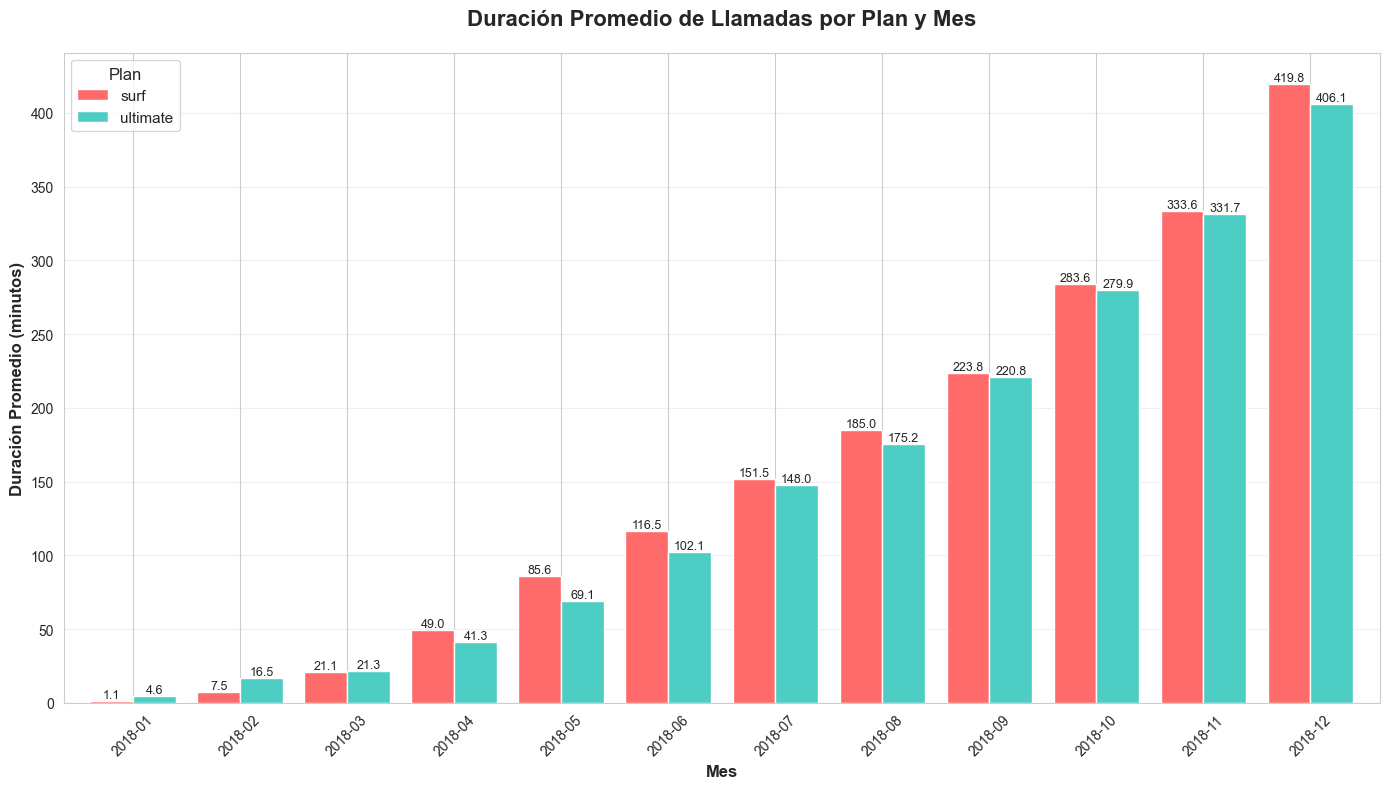

In [2334]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.
# Agrupar por plan y mes, calcular duración promedio
avg_duration = user_data.groupby(['plan', 'month'])['minutes'].mean().reset_index()

# Ver el resultado
print("Duración promedio por plan y mes:")
print(avg_duration.head(24))


# Configurar el estilo
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# Crear gráfico de barras agrupadas
avg_duration_pivot = avg_duration.pivot(index='month', columns='plan', values='minutes')

# Crear el gráfico
ax = avg_duration_pivot.plot(kind='bar', 
                            figsize=(14, 8),
                            color=['#FF6B6B', '#4ECDC4'],  
                            width=0.8)

# Personalizar el gráfico
plt.title('Duración Promedio de Llamadas por Plan y Mes', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Mes', fontsize=12, fontweight='bold')
plt.ylabel('Duración Promedio (minutos)', fontsize=12, fontweight='bold')
plt.legend(title='Plan', title_fontsize=12, fontsize=11)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Añadir valores en las barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=9)

plt.tight_layout()
plt.show()


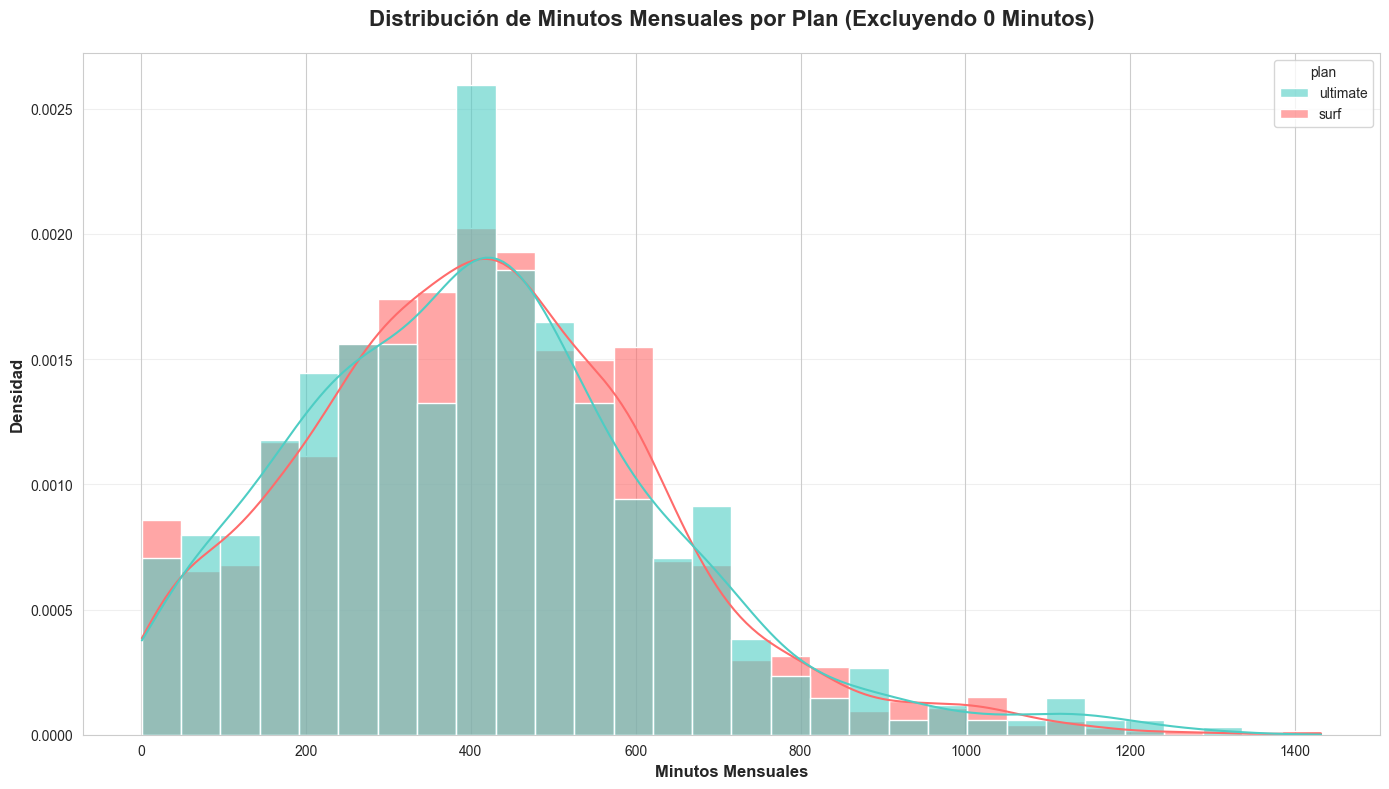

In [2335]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.

#Crear un nuevo DataFrame que excluya los registros donde 'minutes' es igual a 0.
datos_filtrados = user_data[user_data['minutes'] > 0]

plt.figure(figsize=(14, 8))

# Histograma con curvas de densidad
sns.histplot(data=datos_filtrados, x='minutes', hue='plan', 
             bins=30, kde=True, stat='density', common_norm=False,
             palette={'surf': '#FF6B6B', 'ultimate': '#4ECDC4'}, 
             alpha=0.6)

plt.title('Distribución de Minutos Mensuales por Plan (Excluyendo 0 Minutos)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Minutos Mensuales', fontsize=12, fontweight='bold')
plt.ylabel('Densidad', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

[Calcula la media y la variable de la duración de las llamadas para averiguar si los usuarios de los distintos planes se comportan de forma diferente al realizar sus llamadas.]

In [2336]:
# Calcula la media y la varianza de la duración mensual de llamadas.



In [2337]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas



[Elabora las conclusiones sobre el comportamiento de los usuarios con respecto a las llamadas. ¿Su comportamiento varía en función del plan?]

### Mensajes

In [2338]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan



In [2339]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan



[Elabora las conclusiones sobre el comportamiento de los usuarios con respecto a los mensajes. ¿Su comportamiento varía en función del plan?]

### Internet

[Elabora las conclusiones sobre cómo los usuarios tienden a consumir el tráfico de Internet. ¿Su comportamiento varía en función del plan?]

## Ingreso

[Del mismo modo que has estudiado el comportamiento de los usuarios, describe estadísticamente los ingresos de los planes.]

[Elabora las conclusiones sobre cómo difiere el ingreso entre los planes.]

## Prueba las hipótesis estadísticas

[Prueba la hipótesis de que son diferentes los ingresos promedio procedentes de los usuarios de los planes de llamada Ultimate y Surf.]

[Elabora las hipótesis nula y alternativa, escoge la prueba estadística, determina el valor alfa.]

In [2340]:
# Prueba las hipótesis



[Prueba la hipótesis de que el ingreso promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones.]

[Elabora las hipótesis nula y alternativa, escoge la prueba estadística, determina el valor alfa.]

In [2341]:
# Prueba las hipótesis



## Conclusión general

[En esta sección final, enumera tus conclusiones importantes. Asegúrate de que estas abarquen todas las decisiones (suposiciones) importantes que adoptaste y que determinaron la forma elegida para procesar y analizar los datos.]